In [1]:
"""
In this project i will be predicting a customer segementation based on their service
"""

'\nIn this project i will be predicting a customer segementation based on their service\n'

In [2]:
#Importing the libraries for the modelling 

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [5]:
#Downloading and loading the dataset for the model 

In [7]:
path ='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv'
dataset = pd.read_csv(path)
dataset.head()
                        

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [8]:
#Checking to see if there is a missing value in theb dataset 
dataset.isnull().sum()

region     0
tenure     0
age        0
marital    0
address    0
income     0
ed         0
employ     0
retire     0
gender     0
reside     0
custcat    0
dtype: int64

In [9]:
#Information on the dataset 

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   region   1000 non-null   int64  
 1   tenure   1000 non-null   int64  
 2   age      1000 non-null   int64  
 3   marital  1000 non-null   int64  
 4   address  1000 non-null   int64  
 5   income   1000 non-null   float64
 6   ed       1000 non-null   int64  
 7   employ   1000 non-null   int64  
 8   retire   1000 non-null   float64
 9   gender   1000 non-null   int64  
 10  reside   1000 non-null   int64  
 11  custcat  1000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 93.9 KB


In [12]:
#Knowing the statistical knowledge of the dataset
dataset.describe()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
count,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.0220,35.526000,41.684000,0.495000,11.551000,77.535000,2.671000,10.987000,0.047000,0.517000,2.331000,2.487000
std,0.8162,21.359812,12.558816,0.500225,10.086681,107.044165,1.222397,10.082087,0.211745,0.499961,1.435793,1.120306
min,1.0000,1.000000,18.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.0000,17.000000,32.000000,0.000000,3.000000,29.000000,2.000000,3.000000,0.000000,0.000000,1.000000,1.000000
50%,2.0000,34.000000,40.000000,0.000000,9.000000,47.000000,3.000000,8.000000,0.000000,1.000000,2.000000,3.000000
75%,3.0000,54.000000,51.000000,1.000000,18.000000,83.000000,4.000000,17.000000,0.000000,1.000000,3.000000,3.000000
max,3.0000,72.000000,77.000000,1.000000,55.000000,1668.000000,5.000000,47.000000,1.000000,1.000000,8.000000,4.000000


In [13]:
#Correlation of the features : Checking to see how each feature correlate to each other 

In [14]:
dataset.corr()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
region,1.000000,0.016388,0.015034,-0.080637,0.010320,0.023765,-0.057952,0.016335,0.005595,0.050596,-0.065158,-0.023771
tenure,0.016388,1.000000,0.490217,0.154171,0.522952,0.242912,-0.109797,0.520288,0.171143,0.023533,-0.036592,0.166691
age,0.015034,0.490217,1.000000,-0.014433,0.660435,0.327948,-0.154857,0.670047,0.429440,-0.011419,-0.254993,0.056909
marital,-0.080637,0.154171,-0.014433,1.000000,-0.012051,-0.043984,0.001400,-0.002891,-0.078109,0.008345,0.625999,0.083836
address,0.010320,0.522952,0.660435,-0.012051,1.000000,0.226781,-0.128330,0.463291,0.292503,0.008363,-0.201645,0.067913
income,0.023765,0.242912,0.327948,-0.043984,0.226781,1.000000,0.113939,0.516349,-0.083651,0.038706,-0.097591,0.134525
ed,-0.057952,-0.109797,-0.154857,0.001400,-0.128330,0.113939,1.000000,-0.228580,-0.114229,0.006704,0.021045,0.193864
employ,0.016335,0.520288,0.670047,-0.002891,0.463291,0.516349,-0.228580,1.000000,0.277401,0.046016,-0.134683,0.110011
retire,0.005595,0.171143,0.429440,-0.078109,0.292503,-0.083651,-0.114229,0.277401,1.000000,0.053906,-0.140120,0.008908
gender,0.050596,0.023533,-0.011419,0.008345,0.008363,0.038706,0.006704,0.046016,0.053906,1.000000,0.016556,-0.004966


In [15]:
#How each correlate to the target 

In [16]:
correlation_value = dataset.corr()['custcat'].drop('custcat')

In [17]:
correlation_value

region    -0.023771
tenure     0.166691
age        0.056909
marital    0.083836
address    0.067913
income     0.134525
ed         0.193864
employ     0.110011
retire     0.008908
gender    -0.004966
reside     0.082022
Name: custcat, dtype: float64

In [26]:
#Looking at the class wise distribution of the data
dataset['custcat'].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

In [27]:
correlation_metircs = dataset.corr()

<Axes: >

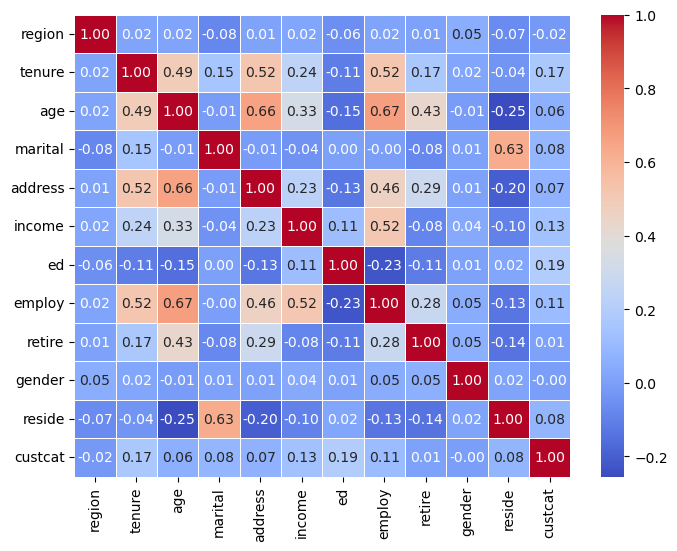

In [28]:
#Data distribution and visualization

plt.figure(figsize = (8,6))
sns.heatmap(correlation_metircs, annot = True, cmap = 'coolwarm', fmt = '.2f',linewidths = 0.5)

In [30]:
#Sorting the correlation of the input features with the target

In [31]:
dataset.corr()['custcat'].drop('custcat').sort_values(ascending = False)

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
address    0.067913
age        0.056909
retire     0.008908
gender    -0.004966
region    -0.023771
Name: custcat, dtype: float64

In [33]:
#Splitting the Dataset into input and target 
X = dataset.drop('custcat', axis = 1)
y = dataset['custcat']

In [34]:
#Normalizing the input features to make the means be zero and the standard deviation be 1

In [36]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [37]:
#Splitting the Dataset into training tha testing set

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_norm,y, test_size = 0.3,random_state = 42)

In [46]:
#Training the model

In [50]:
k = 7
knn_model = KNeighborsClassifier(n_neighbors = k)
knn_model.fit(X_train,y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [51]:
#Making prediction on the model
yhat = knn_model.predict(X_test)

In [52]:
#Printing the accuracy of the model
scores = accuracy_score(y_test, yhat)
print(f"The Accuracy of the model is {np.round(100*scores,2)}%")

The Accuracy of the model is 36.0%


In [54]:
#Choosing the best k for the model
ks = 10
acc = np.zeros((ks))
std_acc = np.zeros((ks))
for n in range (1, ks + 1):
    knn_model_ = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat = knn_model_.predict(X_test)
    acc[n-1] = accuracy_score(y_test,yhat)
    std_acc[n-1] = np.std(yhat == y_test) / (np.sqrt(yhat.shape[0]))

In [55]:
#Plotting the model accuracy of the differernt number of neighbors

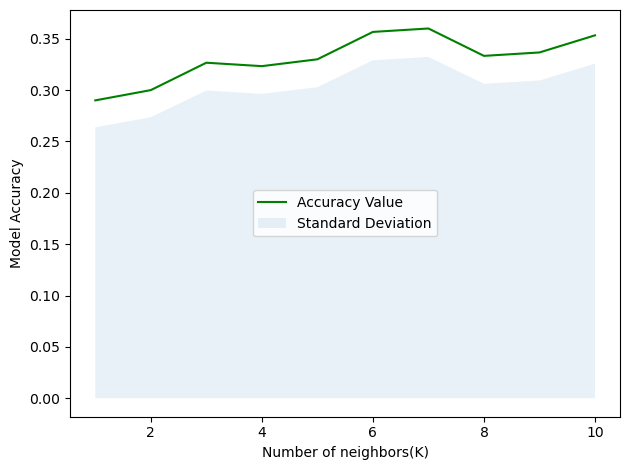

In [58]:
plt.plot(range(1, ks + 1), acc, 'g')
plt.fill_between(range(1, ks + 1), acc -1 * std_acc, alpha = 0.10)
plt.legend(('Accuracy Value','Standard Deviation'))
plt.ylabel("Model Accuracy")
plt.xlabel("Number of neighbors(K)")
plt.tight_layout()
plt.show()

In [60]:
#Printing the best choice for k
print(f"The best accuracy was with {acc.max()}, with , {acc.argmax() + 1}")

The best accuracy was with 0.36, with , 7
